<a href="https://colab.research.google.com/github/Divyanshi-debug/NIRF-GPHD/blob/main/notebooks/GPHD_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv("gphd_2024_1.csv")

In [ ]:
df.head()

,serial_number,ft_year1,pt_year1,ft_year2,pt_year2,ft_year3,pt_year3,total_ft,total_pt,Nphd,GPHD
0,1,278,3,231,0,203,2,712,5,239.0000,16.98
1,2,295,60,238,69,230,71,763,200,321.0000,17.49
2,3,382,31,416,26,122,150,920,207,375.6667,18.87
3,4,230,7,190,5,208,6,628,18,215.3333,16.08
4,5,324,0,396,0,349,0,1069,0,356.3333,20.00


In [ ]:
import matplotlib.pyplot as plt

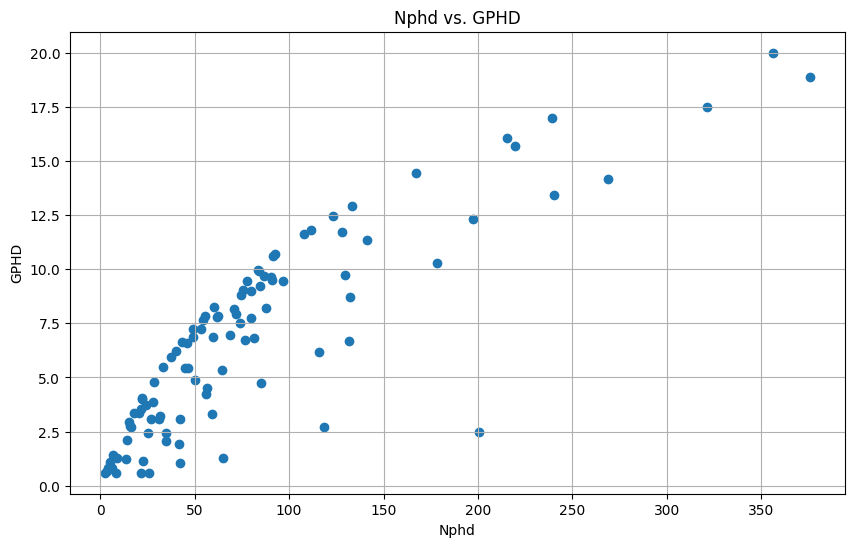

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Nphd'], df['GPHD'])
plt.xlabel('Nphd')
plt.ylabel('GPHD')
plt.title('Nphd vs. GPHD')
plt.grid(True)
plt.show()

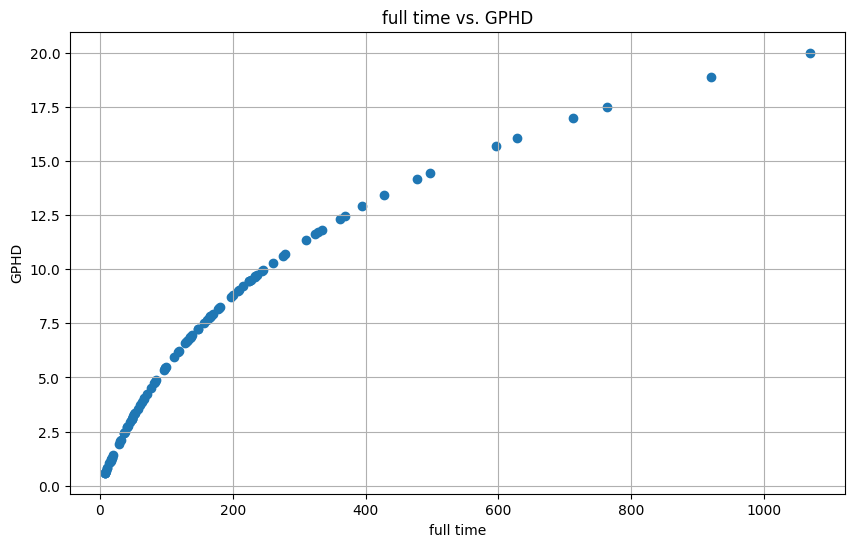

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['total_ft'], df['GPHD'])
plt.xlabel('full time')
plt.ylabel('GPHD')
plt.title('full time vs. GPHD')
plt.grid(True)
plt.show()

In [ ]:
df1=pd.read_csv("gphd_2024_working.csv")

In [ ]:
df1.head()

,serial_number,total_ft,nphd_ft,GPHD,f(nphd)
0,5,1069,356.333333,20.00,1.0000
1,3,920,306.666667,18.87,0.9435
2,2,763,254.333333,17.49,0.8745
3,1,712,237.333333,16.98,0.8490
4,4,628,209.333333,16.08,0.8040


In [ ]:
import matplotlib.pyplot as plt

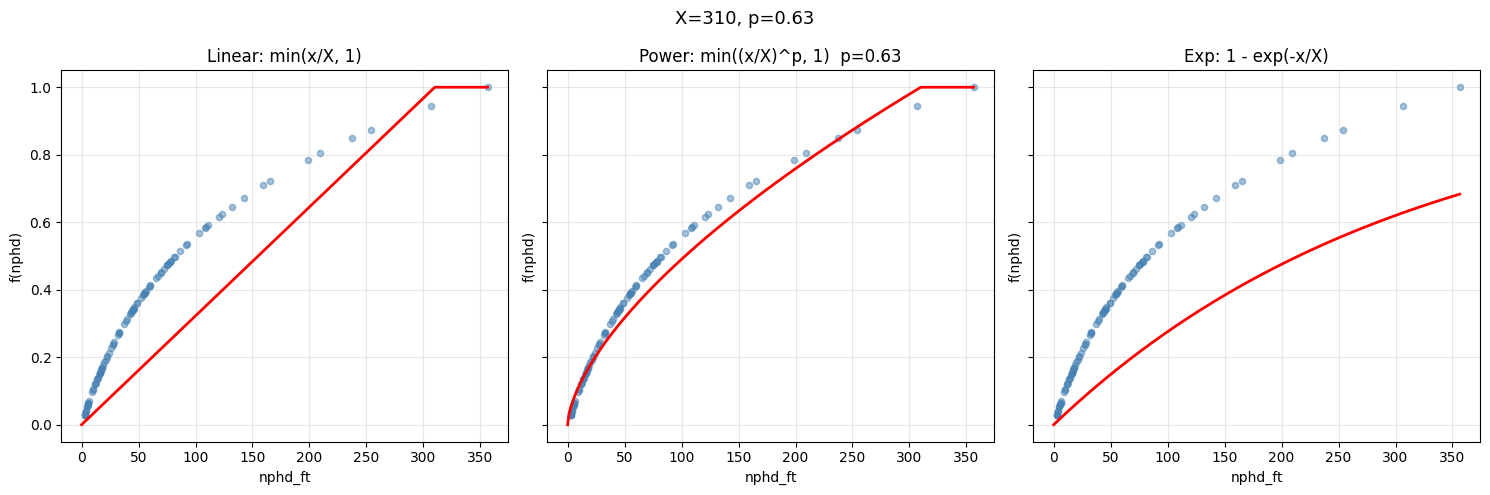

In [ ]:
x = df1['nphd_ft'].values
y = df1['f(nphd)'].values

X = 310
p = 0.63

x_line = np.linspace(0, x.max(), 300)

f_linear = np.minimum(x_line / X, 1)
f_power  = np.minimum((x_line / X) ** p, 1)
f_exp    = 1 - np.exp(-x_line / X)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
titles = ['Linear: min(x/X, 1)', f'Power: min((x/X)^p, 1)  p={p}', 'Exp: 1 - exp(-x/X)']
curves = [f_linear, f_power, f_exp]

for ax, title, curve in zip(axes, titles, curves):
    ax.scatter(x, y, alpha=0.5, s=20, color='steelblue')
    ax.plot(x_line, curve, color='red', linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('nphd_ft')
    ax.set_ylabel('f(nphd)')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'X={X}, p={p}', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.optimize import curve_fit

def power_model(x, X, p):
    return np.minimum((x / X) ** p, 1)

params, _ = curve_fit(power_model, x, y, p0=[310, 0.63])

print(f"Best X = {params[0]:.2f}")
print(f"Best p = {params[1]:.4f}")

Best X = 276.19
Best p = 0.6106


In [ ]:
y_pred = power_model(x, params[0], params[1])

ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"R² = {r2:.4f}")

R² = 0.9897


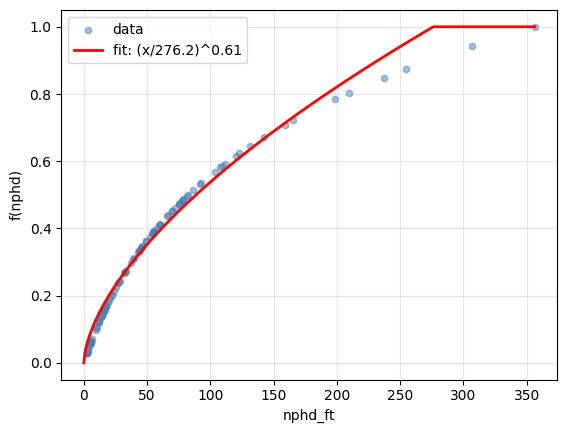

In [ ]:
x_line = np.linspace(0, x.max(), 300)
y_line = power_model(x_line, params[0], params[1])

plt.scatter(x, y, alpha=0.5, s=20, color='steelblue', label='data')
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'fit: (x/{params[0]:.1f})^{params[1]:.2f}')
plt.xlabel('nphd_ft')
plt.ylabel('f(nphd)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
def power_model_fixed_p(x, X):
    return np.minimum((x / X) ** 0.62, 1)

params, _ = curve_fit(power_model_fixed_p, x, y, p0=[300])
print(f"X for this year = {params[0]:.2f}")

X for this year = 271.60


In [ ]:
y_pred = power_model_fixed_p(x, params[0])

ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"R² = {r2:.4f}")

R² = 0.9895
